# Model Comparison and Selection

This notebook records how the model behind the API was chosen. It imports the
same functions that `make train` runs, so the results here cannot drift from the
deployed pipeline.

The target is house price of unit area, measured in 10,000 New Taiwan Dollars
per ping (1 ping = 3.3 m2). All RMSE and MAE figures are in those units.

The order of work is: create a location-disjoint split, establish a baseline,
add EDA-motivated features, tune a bounded set of credible candidates on shared
grouped folds, freeze the winner, then evaluate once on the protected holdout.

In [1]:
import joblib
import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from house_prices import config
from house_prices.data import load_dataset
from house_prices.evaluate import evaluate
from house_prices.features import FeatureEngineer
from house_prices.train import (
    SCORING,
    Candidate,
    default_candidates,
    grouped_cv,
    location_groups,
    run_cv_comparison,
    run_date_ablation,
    select_model,
    split_data,
    train_and_persist,
)

METRICS = ["cv_train_rmse", "cv_rmse", "cv_rmse_std", "cv_mae", "cv_r2", "best_params"]

df = load_dataset()
X_train, X_test, y_train, y_test = split_data(df)
print(f"{len(df)} rows total, {len(X_train)} training, {len(X_test)} protected holdout")
print(
    f"{len(np.unique(location_groups(X_train)))} training locations, "
    f"{len(np.unique(location_groups(X_test)))} holdout locations"
)

414 rows total, 331 training, 83 protected holdout
207 training locations, 52 holdout locations


## 1. Experimental protocol

The 414 observations are split once into 331 training rows and 83 protected
holdout rows. Exact latitude/longitude pairs stay together, producing 207
training locations and 52 unseen holdout locations with zero overlap. The fixed
seed makes the split reproducible. Detailed EDA is restricted to the training
partition.

All model and feature decisions in sections 2 to 5 are made on the 331 training
rows using shuffled 5-fold GroupKFold. Exact locations never cross a fold
boundary. Every candidate and bounded parameter grid is scored on the same
folds, so the numbers are comparable.

The holdout is not used for model or feature selection. It is evaluated once,
after the final model and hyperparameters have been frozen, in section 8.

Every candidate is a scikit-learn `Pipeline` holding the feature transforms and
the estimator together. Because the transforms are fitted inside the pipeline,
each cross-validation fold derives them from its own training rows only.

## 2. Mean baseline

The mean predictor ignores every feature and returns the training mean. It
establishes the minimum useful performance: a real model should clearly
outperform always predicting the training mean.

In [2]:
baseline = [c for c in default_candidates() if c.name == "mean_baseline"]
run_cv_comparison(X_train, y_train, baseline)[["model", *METRICS]].round(3)

,model,cv_train_rmse,cv_rmse,cv_rmse_std,cv_mae,cv_r2,best_params
0,mean_baseline,12.894,12.895,1.606,10.406,-0.037,{}


Grouped-CV RMSE 12.90, MAE 10.41, and R2 approximately zero. R2 is defined by
comparison with this model, so a mean predictor scores near zero by
construction. The small negative value comes from the mean being computed on
each training fold and scored on a different fold.

## 3. Plain linear regression

Linear regression is the first real model. It is simple, its coefficients can be
read directly, and it is cheap to retrain and serve. That makes it a useful
technical benchmark for measuring whether feature engineering and more flexible
estimators earn their extra complexity.

It is fitted here on the six raw columns, with no engineered features.

In [3]:
plain = [c for c in default_candidates() if c.name == "linear_regression"]
run_cv_comparison(X_train, y_train, plain)[["model", *METRICS]].round(3)

,model,cv_train_rmse,cv_rmse,cv_rmse_std,cv_mae,cv_r2,best_params
0,linear_regression,8.272,8.534,1.557,6.359,0.545,{}


Grouped-CV RMSE 8.53 against the baseline's 12.90. The raw features already carry
substantial signal.

## 4. EDA-driven feature engineering

Two features are added, each with a reason taken from `01_eda.ipynb`. Nothing is
added because it is available; each one is a hypothesis that cross-validation
either supports or does not.

**A. Log of MRT distance.** The EDA showed the relationship between distance and
price is curved: the difference between 100 m and 600 m matters more than the
difference between 4,000 m and 4,500 m. A linear model applies one coefficient
across the whole range, so it fits a curve poorly. Taking the log compresses
large distances and makes the relationship closer to linear.

The EDA also reported that the correlation with price strengthens from about
-0.67 to -0.71 under the log. That is a stronger linear relationship with the
target. It is not by itself proof that prediction improves, so cross-validation
decides whether the transform is kept.

**B. House age squared.** The EDA showed price falls with age for roughly two
decades and then rises. A linear model of the form

```
price = b0 + b1 * age
```

can only express a constant rate in one direction. Adding a squared term,

```
price = b0 + b1 * age + b2 * age^2
```

lets the fitted curve bend once, while the estimator stays linear in its
coefficients. This is tested rather than assumed. Squared terms are not
generated for any other feature.

In [4]:
def linear_step(name, **features):
    return Candidate(
        name=name,
        estimator=LinearRegression(),
        scale=True,
        complexity=1,
        purpose="",
        features={"log_mrt_distance": False, "age_squared": False, **features},
    )


progression = [
    linear_step("1. raw columns"),
    linear_step("2. + log10(mrt_distance)", log_mrt_distance=True),
    linear_step("3. + age squared", log_mrt_distance=True, age_squared=True),
]
run_cv_comparison(X_train, y_train, progression)[["model", *METRICS]].round(3)

,model,cv_train_rmse,cv_rmse,cv_rmse_std,cv_mae,cv_r2,best_params
0,1. raw columns,8.272,8.534,1.557,6.359,0.545,{}
1,2. + log10(mrt_distance),7.714,7.758,1.839,5.438,0.624,{}
2,3. + age squared,7.363,7.741,1.337,5.656,0.624,{}


The two hypotheses receive different levels of support:

- The log transform reduces grouped-CV RMSE from 8.534 to 7.758 and MAE from
  6.359 to 5.438. This is a clear improvement for the linear model.
- The squared age term changes grouped-CV RMSE only from 7.758 to 7.741 while
  MAE becomes slightly worse. It is retained in the linear comparison because the
  primary RMSE moves in the expected direction, but the evidence is weak.

These transforms are relevant to linear/Ridge candidates. The selected tree model
uses raw features because monotonic transforms do not add split information.

### A third feature that was rejected

The EDA also suggested a distance-from-center feature: latitude and longitude
only describe location jointly, so a single derived distance to the central area
might give a linear model something more usable.

It is implemented below rather than in the production package, because the
result does not justify shipping it. The center is learned in `fit`, so each
cross-validation fold computes it from its own training rows.

In [5]:
class AddDistanceFromCenter(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Learn the center from training rows only to avoid validation leakage.
        self.center_latitude_ = float(X["latitude"].mean())
        self.center_longitude_ = float(X["longitude"].mean())
        return self

    def transform(self, X):
        out = X.copy()
        out["distance_from_center"] = np.sqrt(
            (X["latitude"] - self.center_latitude_) ** 2
            + (X["longitude"] - self.center_longitude_) ** 2
        )
        return out


def linear_pipeline(*extra_steps):
    return Pipeline([
        ("features", FeatureEngineer()),
        *extra_steps,
        ("scale", StandardScaler()),
        ("model", LinearRegression()),
    ])


cv = grouped_cv()
groups = location_groups(X_train)
for label, pipeline in [
    ("without distance_from_center", linear_pipeline()),
    ("with distance_from_center", linear_pipeline(("center", AddDistanceFromCenter()))),
]:
    scores = cross_validate(
        pipeline, X_train, y_train, cv=cv, groups=groups, scoring=SCORING
    )
    print(f"engineered linear, {label:29} CV RMSE {-scores['test_rmse'].mean():.3f}")

engineered linear, without distance_from_center  CV RMSE 7.741
engineered linear, with distance_from_center     CV RMSE 7.721


The feature moves grouped-CV RMSE only from 7.741 to 7.721, a 0.02 change that is
tiny beside the 1.34 fold standard deviation. This is consistent with it being a
deterministic function of
latitude and longitude, both of which are already in the model. The hypothesis
was tested and rejected, and the feature is not part of the production pipeline.

## 5. Ridge regression

The EDA showed that several location-related predictors overlap, with MRT
distance and longitude correlating at -0.81. Overlapping predictors make
individual coefficients sensitive to small changes in the data. Ridge is linear
regression with an L2 regularization penalty that discourages excessively large
weights, which reduces that sensitivity.

Whether it helps here is a question for cross-validation, not an assumption.
Lasso is run alongside it, since an L1 penalty can remove a predictor entirely.
Both choose their penalty strength from a small predefined grid on the shared
grouped training folds. This is bounded tuning: enough to test the hypothesis
without an open-ended search on a small dataset.

In [6]:
regularized = [
    Candidate(name="no penalty", estimator=LinearRegression(), scale=True,
              complexity=1, purpose=""),
    Candidate(name="ridge", estimator=Ridge(), scale=True, complexity=1, purpose="",
              param_grid={"alpha": (0.01, 0.1, 1.0, 10.0, 100.0, 1000.0)}),
    Candidate(name="lasso", estimator=Lasso(max_iter=10_000), scale=True,
              complexity=1, purpose="",
              param_grid={"alpha": (0.001, 0.01, 0.1, 1.0, 10.0)}),
]
regularized_results = run_cv_comparison(X_train, y_train, regularized)
regularized_results[["model", *METRICS]].round(3)

,model,cv_train_rmse,cv_rmse,cv_rmse_std,cv_mae,cv_r2,best_params
0,no penalty,7.363,7.741,1.337,5.656,0.624,{}
1,ridge,7.492,7.638,1.660,5.448,0.636,{'alpha': 10.0}
2,lasso,7.402,7.702,1.577,5.544,0.630,{'alpha': 0.1}


In [7]:
ridge_params = regularized_results.loc[
    regularized_results["model"] == "ridge", "best_params"
].iloc[0]
lasso_params = regularized_results.loc[
    regularized_results["model"] == "lasso", "best_params"
].iloc[0]
fitted_lasso = regularized[2].build().set_params(
    **{f"model__{key}": value for key, value in lasso_params.items()}
).fit(X_train, y_train)
lasso_coefficients = pd.Series(
    fitted_lasso.named_steps["model"].coef_,
    index=fitted_lasso.named_steps["features"].get_feature_names_out(),
)
print("ridge best parameters:", ridge_params)
print("lasso best parameters:", lasso_params)
print("features lasso set to zero:", list(lasso_coefficients[lasso_coefficients == 0].index))

ridge best parameters: {'alpha': 10.0}
lasso best parameters: {'alpha': 0.1}
features lasso set to zero: []


Regularization is evaluated by the same grouped evidence as every other model.
The selected penalty and score are displayed above rather than assumed.

The bounded Lasso search selects alpha 0.1 but does not set any coefficient
exactly to zero. Ridge selects alpha 10 and improves grouped-CV RMSE from 7.74
to 7.64, a modest gain consistent with overlapping location predictors.

The conclusion for the story: regularization was tested because some predictors
overlap, but it was not the main source of performance improvement. The
improvements came from the EDA-driven feature engineering in section 4.

Ridge is carried into the main comparison because it is the better regularized
linear candidate. Lasso remains documented as a tested alternative.

### The transaction date

The training-only EDA flagged `transaction_date` as weak (r = 0.04) and as a production
problem. The production argument is the stronger one: the training data covers
2012 and 2013 only, so a current date would fall outside the range the model was
fitted on and would not carry the same meaning as the historical feature.

The cost of excluding it can still be measured.

In [8]:
ablation_models = [c for c in default_candidates()
                   if c.name in {"linear_engineered", "random_forest"}]
run_date_ablation(X_train, y_train, ablation_models).round(3)

,model,with_transaction_date,cv_rmse,cv_rmse_std,best_params
0,linear_engineered,False,7.741,1.337,{}
1,linear_engineered,True,7.619,1.251,{}
2,random_forest,False,7.167,1.379,"{'max_depth': None, 'max_features': 0.7, 'min_..."
3,random_forest,True,7.104,1.344,"{'max_depth': 8, 'max_features': 0.7, 'min_sam..."


Including the date improves grouped-CV RMSE by about 0.12 for the linear model
and 0.04 for the forest, so it carries only a small historical market signal.

It is still excluded. The dataset covers only 2012 and 2013. A current date
would sit far outside that training period and would not represent the same
historical relationship, so transaction date is not a valid production feature
for this prototype. The point is not that a caller cannot supply a date, which
they obviously can, but that the value would not mean what the fitted
coefficient assumes it means.

This table records what the exclusion costs.

## 6. Nonlinear comparison

Two tree-based models are included to test whether a model that represents
nonlinearity and interactions without manual feature work does better than the
engineered linear model.

**Random forest.** A decision tree predicts by learning a series of yes/no
splits on the features, for example "is the distance below 500 m". A single tree
can fit its training data closely and generalize poorly. A random forest trains
many trees, each on a different sample of the data and features, and averages
their predictions. It can represent the age curve and interactions between
features without anyone adding an `age^2` column.

**Gradient boosting.** Trees are built one after another, and each new tree
tries to correct the errors left by the ones before it. It is included as a
second nonlinear benchmark.

The tree candidates use the raw input features. Log-distance and squared age help
a linear equation bend, but they add no ordering information to tree splits; an
ablation produced identical histogram-boosting scores, so its production pipeline
omits them.
Each tree family uses a small, predefined grid covering parameters that control flexibility
and regularization. The search stays inside the grouped training folds; the
protected holdout remains unavailable. This bounded search is a proportionate
way to tune 331 rows without pretending an exhaustive search is reliable.

In [9]:
trees = [c for c in default_candidates()
         if c.name in {"random_forest", "gradient_boosting"}]
tree_results = run_cv_comparison(X_train, y_train, trees)
tree_results[["model", *METRICS]].round(3)

,model,cv_train_rmse,cv_rmse,cv_rmse_std,cv_mae,cv_r2,best_params
0,random_forest,4.540,7.167,1.379,5.112,0.673,"{'max_depth': None, 'max_features': 0.7, 'min_..."
1,gradient_boosting,4.363,6.940,1.060,5.071,0.692,"{'l2_regularization': 0.0, 'learning_rate': 0...."


The table reports both training and grouped-validation RMSE. Their gap is a
useful overfitting diagnostic: flexible models fit the training rows more closely,
so selection is based on unseen grouped folds rather than training fit.

## 7. Model comparison

The whole sequence in one table, every row scored on the same folds:

The exact results are regenerated below. The expected progression is from the
mean baseline, through raw and engineered linear models, to bounded tuning of
regularized and nonlinear candidates. Training RMSE is shown beside grouped-CV
RMSE so that apparent fit is never confused with generalization.

The largest linear-model gains come from the EDA-driven log-distance and squared
age features; regularization then tests whether correlated location predictors
benefit from coefficient shrinkage. The final choice is evidence-driven rather
than fixed to a preferred model family.

The distance-from-center experiment is deliberately not in this table. It
produced no improvement and is reported separately in section 4 so that a table
of accepted steps is not padded with a rejected one.

The cell below regenerates the comparison from the production code.

In [10]:
comparison = run_cv_comparison(X_train, y_train)
table = comparison[["model", "purpose", "cv_train_rmse", "cv_rmse",
                    "cv_mae", "cv_r2", "cv_rmse_std", "best_params"]].copy()
table.columns = ["model", "why tested", "train RMSE", "grouped-CV RMSE",
                 "CV MAE", "CV R2", "fold sd", "best parameters"]
table.round(3)

,model,why tested,train RMSE,grouped-CV RMSE,CV MAE,CV R2,fold sd,best parameters
0,mean_baseline,Minimum useful performance; every real model s...,12.894,12.895,10.406,-0.037,1.606,{}
1,linear_regression,Simplest interpretable regression baseline on ...,8.272,8.534,6.359,0.545,1.557,{}
2,linear_engineered,Tests whether EDA-driven transforms capture th...,7.363,7.741,5.656,0.624,1.337,{}
3,ridge_engineered,Tests whether regularization helps overlapping...,7.492,7.638,5.448,0.636,1.660,{'alpha': 10.0}
4,random_forest,Captures nonlinearities and interactions throu...,4.540,7.167,5.112,0.673,1.379,"{'max_depth': None, 'max_features': 0.7, 'min_..."
5,gradient_boosting,Provides a second nonlinear ensemble with diff...,4.363,6.940,5.071,0.692,1.060,"{'l2_regularization': 0.0, 'learning_rate': 0...."


### Selection rule

Every candidate is scored with the same location-grouped folds. The predefined
rule selects the non-baseline candidate with the lowest mean grouped-CV RMSE.
Interpretability, runtime and maintenance remain important design criteria, but
they do not override the primary predictive evidence after a model has entered
the comparison. The final holdout is not consulted by this rule.

In [11]:
selected, reason = select_model(comparison)
print(selected)
print()
print(reason)

gradient_boosting

gradient_boosting has the lowest mean grouped-CV RMSE (6.94) after bounded tuning. It is selected by the predefined primary metric; interpretability and serving cost are secondary properties, not overrides.


The bounded search selects histogram gradient boosting. Its grouped-CV RMSE is
about 6.94, ahead of random forest (7.17), Ridge (7.64), engineered linear
regression (7.74), and raw linear regression (8.53). The mean baseline is 12.90.

The selected model fits the training rows more closely (about 4.36 RMSE) than it
scores on grouped validation folds. That gap is recorded as an overfitting
diagnostic, not hidden. Its bounded parameters limit the individual trees: 7 leaf
nodes, learning rate 0.10, minimum 20 samples per leaf, and no L2 penalty.

Linear regression remains a valuable benchmark and explanation aid, but choosing
it because it is more familiar would override the project's own evidence. The
selection rule is implemented in `select_model`, so new data can change the
winner without rewriting the narrative.

## 8. Holdout evaluation

The selected model is fitted on all 331 training rows and evaluated once on 83
rows from 52 coordinate locations absent from training. `train_and_persist`
repeats the selection above and writes the exact artifact loaded by the API.

In [12]:
metadata = train_and_persist(df, config.MODELS_DIR)
{k: metadata[k] for k in ("model", "cv_rmse", "cv_mae", "cv_r2", "trained_at", "data_sha256")}

{'model': 'gradient_boosting',
 'cv_rmse': 6.9404748793276685,
 'cv_mae': 5.070819913600931,
 'cv_r2': 0.6920743095165265,
 'trained_at': '2026-08-16T07:30:58+00:00',
 'data_sha256': '597d72fcc6c0539e6035a033ddb387db48fff3fb1f3c98fee31fe081c64a9059'}

In [13]:
results = evaluate(df, config.MODELS_DIR, config.REPORTS_DIR)
results

{'model': 'gradient_boosting',
 'evaluation_type': 'protected coordinate-group-disjoint holdout',
 'n_holdout_rows': 83,
 'n_holdout_locations': 52,
 'n_location_overlap': 0,
 'rmse': 10.479015588309922,
 'rmse_bootstrap_95_ci': [5.5440147270980615, 16.148817896544852],
 'mae': 5.903207602597198,
 'r2': 0.5693580551971725,
 'interval_coverage': 0.9156626506024096,
 'interval_mean_width': 21.07038171685087}

The protected location-disjoint holdout returns RMSE 10.48, MAE 5.90 and R2
0.57. This is worse than the 6.94 grouped-CV RMSE, an honest warning that the
small validation estimate was optimistic for these unseen locations. A 2,000-
sample bootstrap places the holdout RMSE 95% interval at roughly 5.54 to 16.15.

One rare sale has an actual target of 117.5 and a prediction near 40.1, an
absolute error of about 77.4. It explains much of the RMSE/MAE gap and shows that
the model is weakest at the expensive tail. This row was not available during
model selection; the result is reported without reopening tuning.

The holdout was not used to compare models, and it is not used to compare them
here.

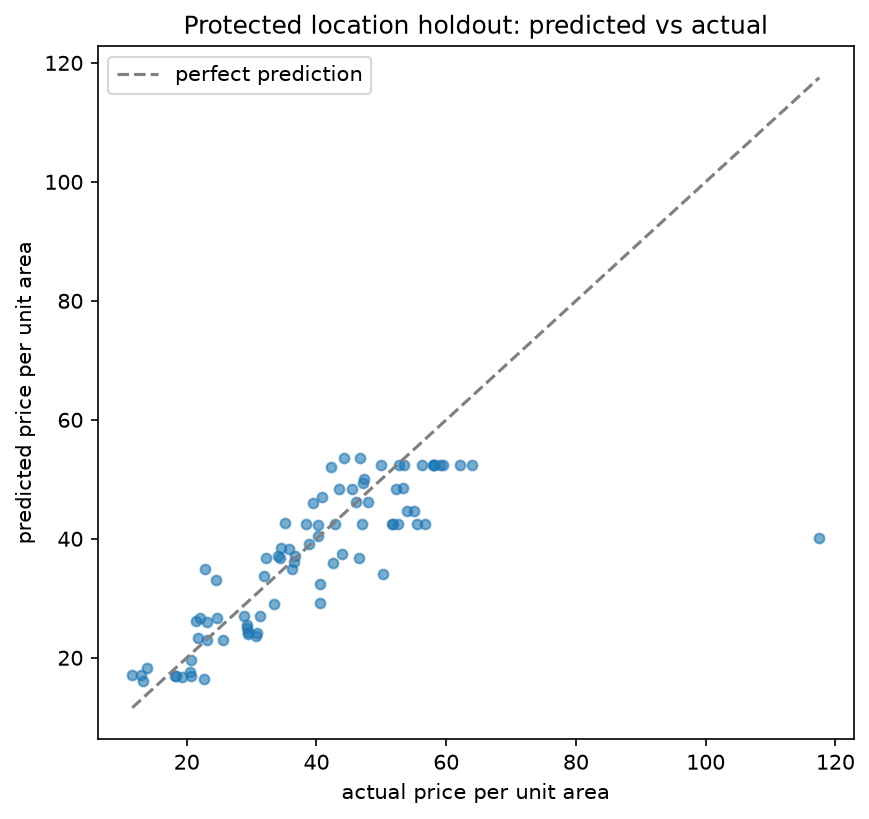

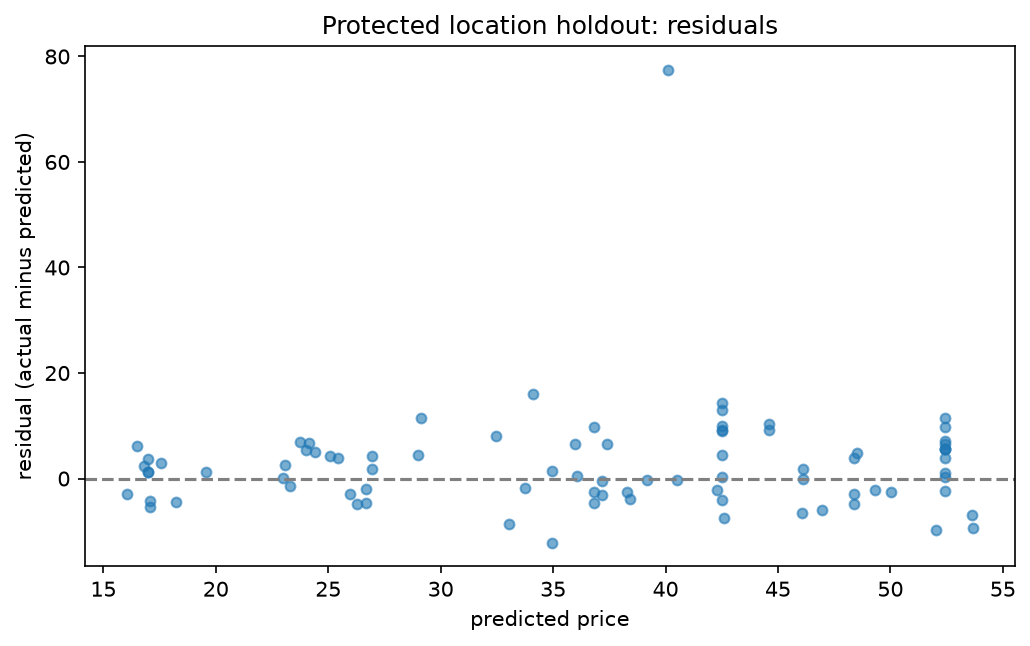

In [14]:
display(Image(str(config.REPORTS_DIR / "model_pred_vs_actual.png")))
display(Image(str(config.REPORTS_DIR / "model_residuals.png")))

Predictions follow the diagonal across most of the price range, while the largest
error sits far above it. The residual view makes the expensive-tail underprediction
visible. This is a material limitation of a small historical dataset, not evidence
that the protected row should be used to choose another model.

## 9. Interpretation

The selected gradient-boosting model has no single slope per input. Interpretation
therefore combines grouped out-of-fold error slices (selection-stage evidence)
with permutation importance on the protected holdout (descriptive final evidence).
Neither should be read as causal.

In [15]:
artifact = joblib.load(config.MODELS_DIR / config.MODEL_FILENAME)
pipeline = artifact["point"]
validation_by_band = pd.DataFrame(
    artifact["metadata"]["validation_diagnostics"]["by_target_band"]
)
validation_by_band.round(2)

,segment,n,rmse,mae
0,low,113,5.58,4.09
1,middle,110,5.40,4.21
2,high,108,9.32,6.90


The grouped out-of-fold diagnostic shows validation RMSE around 5.58 in the low
target band, 5.40 in the middle, and 9.32 in the high band. The model's weakest
region was therefore visible in training-only validation before the holdout was
opened. The high-price limitation is a pattern, not a story invented around one
final-test row.

EDA still explains the feature hypotheses: price has a nonlinear relationship
with MRT distance, the age curve is not purely linear, and several location
variables overlap. These are associations in one district's 2012-2013 records,
not evidence that changing an input would cause a price change.

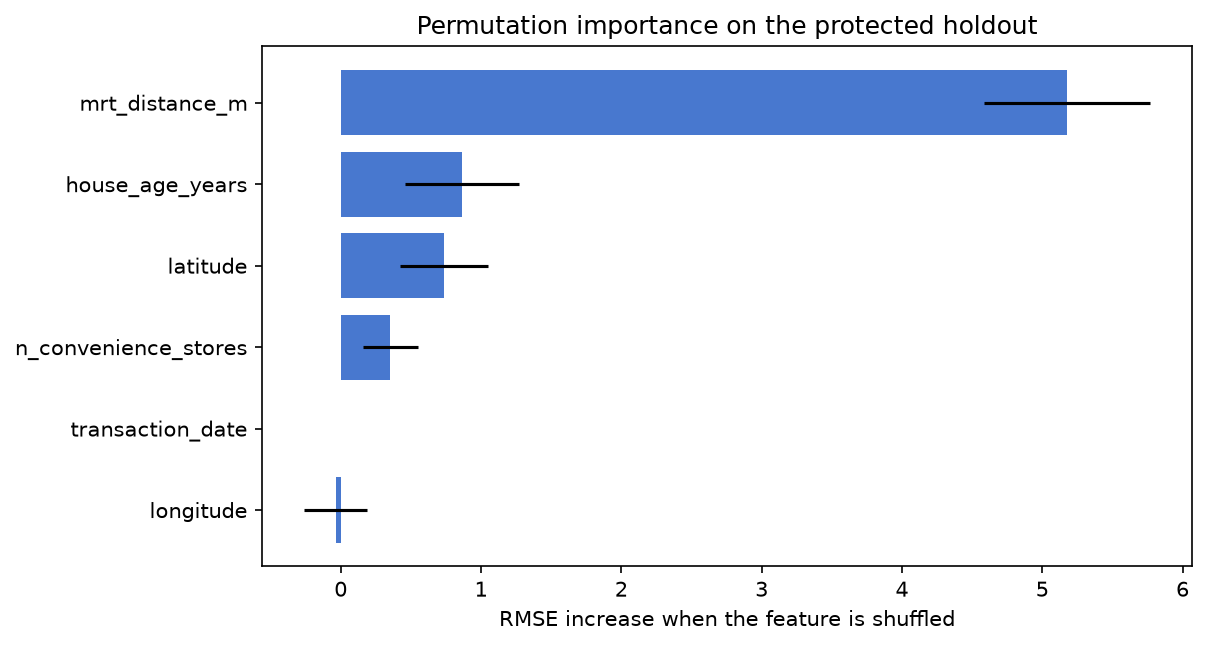

In [16]:
display(Image(str(config.REPORTS_DIR / "model_permutation_importance.png")))

Permutation importance measures the increase in holdout RMSE when one input
column is shuffled. It is computed on the raw input columns, before the
transforms, so it reports the contribution of each API input rather than each
derived feature. Because it uses only 83 protected rows and correlated predictors
can share importance, it is descriptive rather than a stable causal ranking.

## 10. Production decision and limitations

**Selected model.** Histogram gradient boosting over the five raw serving inputs,
with 7 leaf nodes, learning rate 0.10, minimum 20 samples per leaf and no L2
penalty. The dataset holds 414 transactions: 331 rows from 207 locations fit the
model and 83 rows from 52 different locations form the protected holdout. The
artifact evaluated here is the same object loaded by the API. Tree models do not
require feature scaling; linear and Ridge candidates scale inside their pipelines.

**Reason.** It has the lowest mean grouped-CV RMSE after bounded tuning. Linear
regression is retained as an interpretable benchmark, but familiarity is not a
selection criterion. The nonlinear model earns its additional complexity on
training-only validation evidence.

**Limitations.**

- 414 transactions from Sindian District, New Taipei City, recorded in 2012 and
  2013. The model describes that market at that time. Applying it to another
  district or to current prices is extrapolation.
- The protected holdout contains 83 rows and one extreme high-price sale, so RMSE
  has a wide bootstrap interval and the point estimate is unstable.
- High-price properties are underrepresented; both grouped validation and the
  protected holdout show larger errors in that region.
- `transaction_date` is excluded, so the model has no mechanism for market
  drift. Accuracy will degrade as the market moves away from 2013.
- The prediction interval has a fixed width for every property, so it does not
  widen for inputs the model finds unusual. See the appendix.
- The interval's 92% observed coverage is a final finite-sample diagnostic, not
  a guarantee for an individual property or a new market.
- The service refuses inputs outside the ranges seen during training rather than
  returning a number with no empirical support.

**Before running this against a live market.** Current transaction data with a
defined refresh cadence; a time or market-index feature that is valid at
prediction time, to replace the excluded transaction date; monitoring of
prediction error against realised sale prices; and a retraining trigger tied to
that monitoring.

## Appendix: prediction intervals

A point estimate on its own invites false precision, so the API returns a range
alongside it. This is a secondary feature and takes no part in model selection.

### Historical prototype, and why it was replaced

Before the location-disjoint protocol was introduced, the interval used two
quantile gradient-boosting models at the 5th and 95th percentiles. A historical
random-split diagnostic exposed two design problems; none of those old numbers
are used as evidence for the current model.

Coverage was 82% against a 90% design target, so the interval was too narrow.

More seriously, the bounds came from different models than the point estimate.
The point and interval models did not agree, so the estimate did not
sit centrally inside its own interval. For one example house the estimate was
47.2 while the two bounds were 41.8 and 67.0, whose midpoint is 54.4. The
reported number sat near the bottom of a range built around a different model's
opinion. Those figures document the replaced prototype only.

### The current implementation

The interval is now built from the selected model's own errors. Predictions are
made out of fold with location-grouped training folds, the residuals are
collected, and the 5th
and 95th percentiles of those residuals become fixed offsets applied to any
prediction.

Out-of-fold residuals matter here: an in-sample residual understates the error,
because the model has already seen that row.

In [17]:
bounds = artifact["residual_bounds"]
print(f"residual 5th percentile:  {bounds['lower']:+.2f}")
print(f"residual 95th percentile: {bounds['upper']:+.2f}")
print(f"interval width: {bounds['upper'] - bounds['lower']:.2f}")

residual 5th percentile:  -9.16
residual 95th percentile: +11.91
interval width: 21.07


In [18]:
example = pd.DataFrame([{
    "house_age_years": 10.0,
    "mrt_distance_m": 250.0,
    "n_convenience_stores": 6,
    "latitude": 24.975,
    "longitude": 121.540,
}])
point = float(artifact["point"].predict(example)[0])
print(f"point estimate: {point:.1f} (10,000 TWD per ping)")
print(f"interval:       {point + bounds['lower']:.1f} to {point + bounds['upper']:.1f}")
print(f"observed holdout coverage: {results['interval_coverage']:.0%}")

point estimate: 44.4 (10,000 TWD per ping)
interval:       35.2 to 56.3
observed holdout coverage: 92%


The range is derived from grouped out-of-fold residuals of the selected model, so
the point estimate and error offsets come from one model family. The printed
offsets need not be symmetric because the model's errors need not be symmetric.

Coverage measured once on the protected location-disjoint holdout is 92% against
the 90% design target. It is a final observed diagnostic on only 83 rows, not a
guarantee for an individual transaction or another market. Future repeated model
development would require a newly protected test set or nested evaluation.

**Known limitation, not scheduled for change here.** The offsets are constant, so
every property receives the same interval width. A property the model finds
unusual deserves a wider range than a typical one, and this design does not
provide that. It is recorded as a limitation rather than worked around.

Removing the two separate quantile models makes the serving path simpler: one
selected point-estimation pipeline and two residual offsets instead of three
independently fitted pipelines.

**How serving handles inputs outside the fitted range.** The API does not
extrapolate. If any input falls outside the range the model was fitted on, it
returns 422 with an `outside_model_support` error naming the offending fields
and their supported ranges, and it does not clip the input to the nearest
supported value. The earlier example of a 95-year-old property 9 km from a
station is refused rather than answered because those values have no support in
the fitted training data.